# MobileNetV2 con pesos de ImageNet

Este notebook usa **MobileNetV2 directamente con pesos de ImageNet**, manteniendo sus **clases originales** y sin entrenar una CNN adicional.

Se incluyen dos usos:
1. Clasificación directa con las 1000 clases originales de ImageNet.
2. Extracción de características usando la salida previa a la capa de predicción.


## 1) Configuración de rutas y parámetros


In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive

# Montar Google Drive
drive.mount("/content/drive")

# Ruta de la carpeta en Google Drive
BASE_DIR = "/content/drive/MyDrive/dataset_smile"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Verificar que las carpetas sí existen
for path in [BASE_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(path, "->", os.path.exists(path))

# MobileNetV2 con include_top=True usa entrada 224x224x3
IMG_SIZE = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE


Mounted at /content/drive
/content/drive/MyDrive/dataset_smile -> True
/content/drive/MyDrive/dataset_smile/train -> True
/content/drive/MyDrive/dataset_smile/val -> True
/content/drive/MyDrive/dataset_smile/test -> True


## 2) Cargar MobileNetV2 original de ImageNet


In [2]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

# Modelo original con:
# - pesos de ImageNet
# - capa superior incluida
# - 1000 clases originales
mobilenetv2 = MobileNetV2(
    weights="imagenet",
    include_top=True,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

mobilenetv2.trainable = False

mobilenetv2.summary()


14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,538,984 (13.50 MB)

## 3) Usar MobileNetV2 como extractor de características

Se toma la salida de la penúltima capa del mismo modelo ImageNet. Esto conserva el modelo original y no agrega una cabeza nueva de clasificación.


In [3]:
# Salida previa a la capa final 'predictions'.
# En MobileNetV2 corresponde al vector de características antes de clasificar.
feature_extractor = tf.keras.Model(
    inputs=mobilenetv2.input,
    outputs=mobilenetv2.layers[-2].output,
    name="mobilenetv2_feature_extractor"
)

feature_extractor.trainable = False

print("Salida del extractor:", feature_extractor.output_shape)


Salida del extractor: (None, 1280)


## 4) Clasificación directa de una imagen con clases originales de ImageNet


Top 5 predicciones ImageNet:
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
pajama: 0.1711
lab_coat: 0.1266
apron: 0.0733
candle: 0.0712
kimono: 0.0248


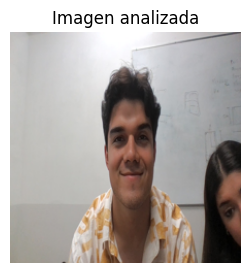

In [4]:
# Cambia esta ruta por la imagen que quieras analizar
img_path = "/content/drive/MyDrive/WIN_20260427_19_57_40_Pro.jpg"

img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
x = np.asarray(img).astype("float32")
x = np.expand_dims(x, axis=0)
x_pre = preprocess_input(x.copy())

preds = mobilenetv2.predict(x_pre, verbose=0)

print("Top 5 predicciones ImageNet:")
for imagenet_id, label, prob in decode_predictions(preds, top=5)[0]:
    print(f"{label}: {prob:.4f}")

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis("off")
plt.title("Imagen analizada")
plt.show()


## 5) Extraer características de una sola imagen


In [5]:
features = feature_extractor.predict(x_pre, verbose=0)

print("Shape del vector de características:", features.shape)
print("Primeros 10 valores:")
print(features[0][:10])


Shape del vector de características: (1, 1280)
Primeros 10 valores:
[8.5934348e-02 2.3167916e-01 1.2180155e-01 7.5131047e-01 1.2432808e+00
 2.3639770e-01 1.7018077e+00 1.0225237e-03 4.7951855e-02 7.9424953e-01]


## 6) Crear datasets desde carpetas sin modificar clases del modelo

Las carpetas se usan únicamente para cargar imágenes y extraer vectores de características. No se entrena ni se cambia MobileNetV2.


In [6]:
def make_image_dataset(directory, shuffle=False):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH,
        shuffle=shuffle
    )

train_ds = make_image_dataset(TRAIN_DIR, shuffle=False)
val_ds   = make_image_dataset(VAL_DIR, shuffle=False)
test_ds  = make_image_dataset(TEST_DIR, shuffle=False)

# Estas clases son solo las etiquetas de tus carpetas.
# No sustituyen las 1000 clases originales de ImageNet.
folder_class_names = train_ds.class_names
print("Clases de carpetas:", folder_class_names)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)


Found 1400 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Clases de carpetas: ['0_no_smile', '1_smile']


## 7) Extraer características de todo el dataset


In [ ]:
def extract_features(ds):
    all_features = []
    all_labels = []

    for images, labels in ds:
        images_pre = preprocess_input(tf.cast(images, tf.float32))
        batch_features = feature_extractor.predict(images_pre, verbose=0)
        all_features.append(batch_features)
        all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_features, all_labels

X_train_features, y_train = extract_features(train_ds)
X_val_features, y_val     = extract_features(val_ds)
X_test_features, y_test   = extract_features(test_ds)

print("X_train_features:", X_train_features.shape)
print("X_val_features:", X_val_features.shape)
print("X_test_features:", X_test_features.shape)


## 8) Guardar características extraídas


In [ ]:
OUT_DIR = "/content/drive/MyDrive/mobilenetv2_features"
os.makedirs(OUT_DIR, exist_ok=True)

np.save(os.path.join(OUT_DIR, "X_train_features.npy"), X_train_features)
np.save(os.path.join(OUT_DIR, "y_train.npy"), y_train)

np.save(os.path.join(OUT_DIR, "X_val_features.npy"), X_val_features)
np.save(os.path.join(OUT_DIR, "y_val.npy"), y_val)

np.save(os.path.join(OUT_DIR, "X_test_features.npy"), X_test_features)
np.save(os.path.join(OUT_DIR, "y_test.npy"), y_test)

print("Características guardadas en:", OUT_DIR)
